# Smoke test: Qwen2.5-VL-7B-Instruct as an answerer

Validates the answerer harness end to end on one model **before** committing to a
multi-hour run across six models and three datasets.

Qwen2.5-VL goes first for two reasons: it is ungated, and **Patho-R1-7B is a Qwen2.5-VL
finetune**, so this same adapter is what the strongest candidate will use. Getting it
right here de-risks the model that matters most.

## What this is actually checking

Not "does it load" - that is the easy part. The judge pipeline already produced a model
that loaded without error, reported sensible memory use, and generated fluent, confident,
completely wrong descriptions (InternVL under 4-bit quantization). The checks below are
built to catch that class of failure:

1. **Loads at bf16 on one GPU, no CPU offload.** `device_map` silently offloads when a
   model does not fit, which turns an hours-long run into a days-long one.
2. **Describes a real pathology image plausibly.** A free-text description is the cheapest
   way to detect a corrupted vision tower - a broken model still emits fluent text, but it
   stops being about the image.
3. **Answers real MCQs from all three datasets** and is parsed correctly by `metrics.py`.
4. **The image actually matters.** Same questions, image withheld. If blind accuracy
   matches full-context accuracy, either the questions are answerable from text alone
   (a dataset finding) or the image is not reaching the model (a harness bug). This
   distinction is the whole point of sub-pillar 3b, so it must be verified before the
   real run, not discovered inside it.
5. **Option order matters.** Same questions, options shuffled. Large swings mean
   positional bias.
6. **Throughput measured**, so the full run can be costed rather than guessed at.

In [1]:
import os
import sys

# Pick the GPU BEFORE torch initializes CUDA. GPUs 0-2 are busy with the Qwen judge's
# Benchmark 5 run; 3-7 are free.
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

sys.path.insert(0, os.path.abspath(".."))

import collections
import time

import torch

import tasks
from answerer_models import build_mcq_prompt, load_answerer
from metrics import parse_choice, position_bias, score_predictions

MODEL_KEY = "qwen25vl"
N_PER_DATASET = 20   # enough to see systematic behaviour, small enough to iterate on
print(torch.__version__, torch.cuda.device_count(), "visible GPU(s)")

2.11.0+cu128 1 visible GPU(s)


## 1. Load, and verify where the weights actually landed

In [2]:
t0 = time.time()
model = load_answerer(MODEL_KEY, device="cuda:0")  # logical 0 == physical 3
print(f"loaded in {time.time() - t0:.1f}s")

devices = collections.Counter(str(p.device) for p in model.model.parameters())
offloaded = [d for d in devices if d in ("cpu", "meta", "disk")]
print(f"parameter devices: {dict(devices)}")
print(f"dtypes: {collections.Counter(str(p.dtype) for p in model.model.parameters())}")
print(f"memory: {model.memory_summary()}")
assert not offloaded, f"model offloaded to {offloaded} - it will be unusably slow"
print("OK: fully resident on GPU, no offload")

/data/mn27889/miniconda3/envs/path-opendata-vlms/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 729/729 [00:04<00:00, 169.74it/s]


loaded in 11.3s
parameter devices: {'cuda:0': 729}
dtypes: Counter({'torch.bfloat16': 729})
memory: allocated 15.45 GiB | reserved 15.45 GiB
OK: fully resident on GPU, no offload


## 2. Does it see the image?

Free-text description of a real PathOPEN slide. The point is not to grade the answer but
to confirm the model is describing *this* image: tissue, cells, staining. Generic text
that would fit any image means the vision path is broken, which is exactly how the 4-bit
InternVL failure presented in the judge pipeline.

In [3]:
pathopen = tasks.load_pathopen_mcq(shuffle_seed=0)
print(f"{len(pathopen)} PathOPEN MCQ tasks")

sample = pathopen[0]
print(f"image: {os.path.basename(sample.image_path)} ({sample.magnification}, {sample.organ})")
description = model.answer(
    sample.image_path,
    "Describe this pathology image in 2-3 sentences: tissue type, staining, and any "
    "notable cellular features.",
    max_new_tokens=120,
)
print("\n--- description ---")
print(description)

229 PathOPEN MCQ tasks
image: img_pathopen_153_03_orig.jpeg (50x, Head/Neck - Ear)

--- description ---
This pathology image appears to be a section of skin tissue stained with hematoxylin and eosin (H&E). The H&E stain highlights the nuclei in blue and the cytoplasm in pink. Notable cellular features include a dense infiltrate of lymphocytes and plasma cells within the dermis, suggesting an inflammatory process. The epidermis shows some hyperplasia, with thickened rete ridges, which could indicate a reactive or neoplastic process.


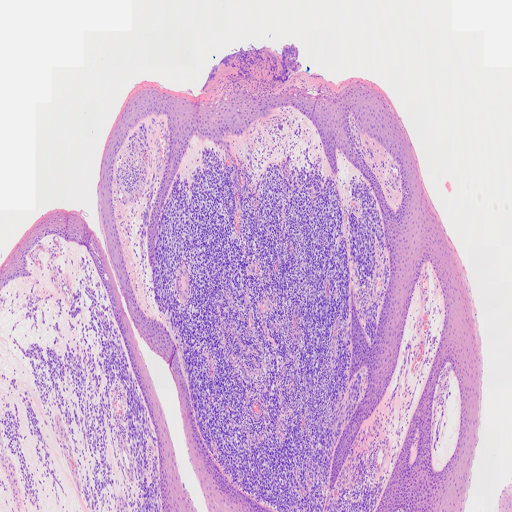

In [4]:
from PIL import Image

# Look at the slide yourself - an automated check cannot tell a plausible description
# from an accurate one, and this is the step where a human eye is worth more than an assert.
Image.open(sample.image_path).convert("RGB").resize((512, 512))

## 3. MCQ answering across all three datasets

Each dataset stores options differently (PathOPEN in separate columns, PathMMU/PatchVQA
as letter-prefixed lists with 2-16 options), so all three are exercised here rather than
trusting that one generalises.

In [5]:
task_sets = {
    "PathOPEN": pathopen[:N_PER_DATASET],
    "PathMMU": tasks.load_pathmmu_mcq(shuffle_seed=0)[:N_PER_DATASET],
    "PatchVQA": tasks.load_patchvqa_mcq(shuffle_seed=0)[:N_PER_DATASET],
}


def run_condition(task_list, blind=False, shuffle_seed=None, show=0):
    """Predictions for one condition. Returns records shaped for `score_predictions`."""
    records, timings = [], []
    for i, task in enumerate(task_list):
        item = task.shuffled(shuffle_seed) if shuffle_seed is not None else task
        prompt = build_mcq_prompt(item.question, item.lettered_options(), blind=blind)
        t = time.time()
        response = model.answer(None if blind else item.image_path, prompt)
        timings.append(time.time() - t)
        index, method = parse_choice(response, item.options)
        records.append({"item_id": item.item_id, "options": item.options,
                        "correct_index": item.correct_index, "predicted_index": index,
                        "parse_method": method, "raw_response": response})
        if i < show:
            mark = "OK " if index == item.correct_index else "MISS"
            print(f"  {mark} got={response[:34]!r} -> {index} ({method}), "
                  f"correct={item.correct_letter}")
    return records, timings


full_results = {}
for name, task_list in task_sets.items():
    print(f"\n=== {name} ({len(task_list)} items) ===")
    records, timings = run_condition(task_list, show=3)
    full_results[name] = records
    stats = score_predictions(records)
    print(f"  accuracy {stats['accuracy']}%  (chance {stats['chance_accuracy']}%)  "
          f"parse_rate {stats['parse_rate']}%  {sum(timings) / len(timings):.2f}s/item")
    print(f"  parse methods: {stats['parse_methods']}")


=== PathOPEN (20 items) ===
  OK  got='B' -> 1 (bare_letter), correct=B
  OK  got='B' -> 1 (bare_letter), correct=B
  OK  got='B' -> 1 (bare_letter), correct=B
  accuracy 45.0%  (chance 20.0%)  parse_rate 100.0%  0.87s/item
  parse methods: {'bare_letter': 20}

=== PathMMU (20 items) ===
  MISS got='D' -> 3 (bare_letter), correct=A
  OK  got='C' -> 2 (bare_letter), correct=C
  OK  got='D' -> 3 (bare_letter), correct=D
  accuracy 60.0%  (chance 25.0%)  parse_rate 100.0%  0.24s/item
  parse methods: {'bare_letter': 20}

=== PatchVQA (20 items) ===
  MISS got='B' -> 1 (bare_letter), correct=D
  MISS got='F' -> 5 (bare_letter), correct=B
  OK  got='B' -> 1 (bare_letter), correct=B
  accuracy 15.0%  (chance 15.48%)  parse_rate 100.0%  0.24s/item
  parse methods: {'bare_letter': 20}


## 4. Does the image matter? (blind condition, sub-pillar 3b)

The same questions with the image withheld. Two very different things produce a small
full-vs-blind gap, and they must not be confused:

- **the questions are answerable from text alone** - a real finding about the dataset,
  and precisely what sub-pillar 3b exists to quantify;
- **the image never reached the model** - a harness bug that would invalidate every
  number in Pillars 3b and 4.

Section 2 already established the model can see images, so a small gap here points at the
dataset rather than the harness. That ordering is deliberate.

In [6]:
print(f"{'dataset':10s} {'full':>8s} {'blind':>8s} {'gap':>8s}  interpretation")
for name, task_list in task_sets.items():
    blind_records, _ = run_condition(task_list, blind=True)
    full_acc = score_predictions(full_results[name])["accuracy"]
    blind_acc = score_predictions(blind_records)["accuracy"]
    gap = round(full_acc - blind_acc, 2)
    note = ("image is being used" if gap > 5 else
            "little image dependence - check section 2 passed")
    print(f"{name:10s} {full_acc:7.1f}% {blind_acc:7.1f}% {gap:7.1f}pp  {note}")

dataset        full    blind      gap  interpretation
PathOPEN      45.0%    45.0%     0.0pp  little image dependence - check section 2 passed
PathMMU       60.0%    40.0%    20.0pp  image is being used
PatchVQA      15.0%    15.0%     0.0pp  little image dependence - check section 2 passed


## 5. Does option order matter? (position-shuffle, sub-pillar 3b)

Three different shuffles of the same questions. A model reading the options should score
about the same each time; one keying on position will swing. `predicted_pct` vs
`truth_pct` shows the bias directly - predictions piling onto "A" while ground truth is
spread evenly is the signature.

In [7]:
shuffle_accuracies = {}
for name, task_list in task_sets.items():
    accuracies = []
    for seed in (1, 2, 3):
        records, _ = run_condition(task_list, shuffle_seed=seed)
        accuracies.append(score_predictions(records)["accuracy"])
        if seed == 1:
            bias = position_bias(records)
            print(f"{name} seed1 position bias:")
            print(f"    predicted {bias['predicted_pct']}")
            print(f"    truth     {bias['truth_pct']}")
    shuffle_accuracies[name] = accuracies
    spread = max(accuracies) - min(accuracies)
    print(f"{name}: {accuracies} -> spread {spread:.1f}pp\n")

PathOPEN seed1 position bias:
    predicted {'A': 25.0, 'B': 30.0, 'C': 30.0, 'D': 5.0, 'E': 10.0, 'F': 0.0}
    truth     {'A': 25.0, 'B': 10.0, 'C': 40.0, 'D': 5.0, 'E': 20.0, 'F': 0.0}
PathOPEN: [40.0, 30.0, 40.0] -> spread 10.0pp

PathMMU seed1 position bias:
    predicted {'A': 30.0, 'B': 35.0, 'C': 10.0, 'D': 25.0, 'E': 0.0, 'F': 0.0}
    truth     {'A': 15.0, 'B': 35.0, 'C': 15.0, 'D': 35.0, 'E': 0.0, 'F': 0.0}
PathMMU: [55.0, 60.0, 55.0] -> spread 5.0pp

PatchVQA seed1 position bias:
    predicted {'A': 11.1, 'B': 27.8, 'C': 11.1, 'D': 5.6, 'E': 27.8, 'F': 16.7}
    truth     {'A': 26.3, 'B': 15.8, 'C': 21.1, 'D': 21.1, 'E': 15.8, 'F': 0.0}
PatchVQA: [15.0, 20.0, 25.0] -> spread 10.0pp



## 6. Verdict and cost projection

In [8]:
_, timings = run_condition(task_sets["PathOPEN"][:10])
per_item = sum(timings) / len(timings)

n_tasks = len(tasks.load_all_mcq(shuffle_seed=0))
# full + blind + 3 shuffles = 5 predictions per task
calls_per_model = n_tasks * 5
hours = calls_per_model * per_item / 3600

print(f"throughput           {per_item:.2f}s/item")
print(f"tasks (3 datasets)   {n_tasks}")
print(f"calls per model      {calls_per_model} (full + blind + 3 shuffles)")
print(f"per model            {hours:.1f}h")
print(f"6 models sequential  {hours * 6:.1f}h")
print(f"6 models on 5 GPUs   {hours * 2:.1f}h (2 waves)")

print("\nchecklist before wiring the full run:")
print("  [ ] description in section 2 is about THIS slide, not generic")
print("  [ ] accuracy comfortably above chance on all three datasets")
print("  [ ] parse_rate near 100% (low rate = prompt problem, not knowledge)")
print("  [ ] blind accuracy clearly below full")
print("  [ ] shuffle spread small")

throughput           0.87s/item
tasks (3 datasets)   1428
calls per model      7140 (full + blind + 3 shuffles)
per model            1.7h
6 models sequential  10.4h
6 models on 5 GPUs   3.5h (2 waves)

checklist before wiring the full run:
  [ ] description in section 2 is about THIS slide, not generic
  [ ] accuracy comfortably above chance on all three datasets
  [ ] parse_rate near 100% (low rate = prompt problem, not knowledge)
  [ ] blind accuracy clearly below full
  [ ] shuffle spread small


In [9]:
# Free the GPU so the next smoke test can use it.
del model
torch.cuda.empty_cache()
print("released")

released
